#  Previsão de Preço de Veículos Usados no Brasil

> ⚠️ **Este conteúdo é destinado apenas para fins educacionais. Os dados exibidos são ilustrativos e podem não corresponder a situações reais.**

---

## Metodologia: CRISP-DM

| Fase | Descrição |
|---|---|
| 1️⃣ Entendimento do Negócio | Prever o valor de venda de veículos usados no Brasil |
| 2️⃣ Entendimento dos Dados | Análise Exploratória (EDA) |
| 3️⃣ Preparação dos Dados | Limpeza, imputação, feature engineering, encoding |
| 4️⃣ Modelagem | Comparação de 7 algoritmos de regressão |
| 5️⃣ Avaliação | Métricas + rastreamento com MLflow |
| 6️⃣ Implantação | Deploy no Streamlit.io |

**Dataset:** 10.000 registros de veículos usados  
**Variável alvo:** `Valor_Venda` (R$)

### Instalar libs

In [1]:
import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

#import mlflow
#import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Diretórios de saída
os.makedirs('eda_outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print(' Imports concluídos com sucesso!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   sklearn importado')
#print(f'   mlflow  {mlflow.__version__}')

 Imports concluídos com sucesso!
   pandas  2.2.2
   numpy   2.0.2
   sklearn importado


In [2]:
df = pd.read_csv('/content/dataset_final.csv')

In [3]:
df.head()

,Marca,Modelo,Ano,Quilometragem,Cor,Cambio,Combustivel,Portas,Valor_Venda,idade_carro
0,Nissan,Frontier,2000,117290,Cinza,Manual,Gasolina,4,43413.0,26
1,Ford,Ranger,2000,141406,Preto,Manual,Flex,4,33267.8,26
2,Toyota,Hilux,2000,138468,Branco,Manual,Flex,2,51867.4,26
3,Renault,Sandero,2000,105311,Azul,Manual,Gasolina,2,22289.8,26
4,Renault,Duster,2000,31654,Prata,Automático,Diesel,2,35878.2,26


### Aplicar onehotencoder nas colunas categoricas

In [4]:
df.columns.tolist()

['Marca',
 'Modelo',
 'Ano',
 'Quilometragem',
 'Cor',
 'Cambio',
 'Combustivel',
 'Portas',
 'Valor_Venda',
 'idade_carro']

In [5]:
colunas = ['Marca', 'Modelo', 'Cor', 'Cambio', 'Combustivel']

In [6]:
lista_marcas = df['Marca'].unique().tolist()
lista_modelo = df['Modelo'].unique().tolist()
lista_cor = df['Cor'].unique().tolist()
lista_cambio = df['Cambio'].unique().tolist()
lista_combustivel = df['Combustivel'].unique().tolist()

In [7]:
print('Marcas:', lista_marcas,
      '\nModelos:',lista_modelo,
      '\nCor:', lista_cor,
      '\nCamvbio:', lista_cambio,
      '\nCombustivel:',lista_combustivel)

Marcas: ['Nissan', 'Ford', 'Toyota', 'Renault', 'Fiat', 'Jeep', 'Honda', 'Volkswagen', 'Hyundai', 'Chevrolet'] 
Modelos: ['Frontier', 'Ranger', 'Hilux', 'Sandero', 'Duster', 'Kicks', 'Ka', 'Corolla', 'Mobi', 'Renegade', 'Compass', 'HR-V', 'T-Cross', 'Toro', 'HB20S', 'Yaris', 'EcoSport', 'Onix', 'Polo', 'Argo', 'Kwid', 'Virtus', 'Civic', 'Cronos', 'Gol', 'Versa', 'Creta', 'HB20', 'S10', 'Tracker', 'Onix Plus', 'Fit'] 
Cor: ['Cinza', 'Preto', 'Branco', 'Azul', 'Prata', 'Vermelho'] 
Camvbio: ['Manual', 'Automático'] 
Combustivel: ['Gasolina', 'Flex', 'Diesel']


### As variaveis categoricas serão tratadas pelo OnehotEncoder.
### Serão criadas novas features a partir da coluna e os valores unicos em cada linha.
### A criação das novas colunas será feita no preprocessamento dos dados no Pipeline.

### Apenas para mostrar o processo de criação de novas features feita pelo OnehotEncoder.

In [8]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_features = encoder.fit_transform(df[colunas])

# Create a DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(colunas))

# Concatenate the original DataFrame with the new encoded features, dropping the original categorical columns
df_encoded = pd.concat([df.drop(columns=colunas), encoded_df], axis=1)

# Display the first few rows of the new DataFrame
display(df_encoded.head())

,Ano,Quilometragem,Portas,Valor_Venda,idade_carro,Marca_Chevrolet,Marca_Fiat,Marca_Ford,Marca_Honda,Marca_Hyundai,...,Cor_Branco,Cor_Cinza,Cor_Prata,Cor_Preto,Cor_Vermelho,Cambio_Automático,Cambio_Manual,Combustivel_Diesel,Combustivel_Flex,Combustivel_Gasolina
0,2000,117290,4,43413.0,26,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2000,141406,4,33267.8,26,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,2000,138468,2,51867.4,26,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,2000,105311,2,22289.8,26,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,2000,31654,2,35878.2,26,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [9]:
df_encoded.columns

Index(['Ano', 'Quilometragem', 'Portas', 'Valor_Venda', 'idade_carro',
       'Marca_Chevrolet', 'Marca_Fiat', 'Marca_Ford', 'Marca_Honda',
       'Marca_Hyundai', 'Marca_Jeep', 'Marca_Nissan', 'Marca_Renault',
       'Marca_Toyota', 'Marca_Volkswagen', 'Modelo_Argo', 'Modelo_Civic',
       'Modelo_Compass', 'Modelo_Corolla', 'Modelo_Creta', 'Modelo_Cronos',
       'Modelo_Duster', 'Modelo_EcoSport', 'Modelo_Fit', 'Modelo_Frontier',
       'Modelo_Gol', 'Modelo_HB20', 'Modelo_HB20S', 'Modelo_HR-V',
       'Modelo_Hilux', 'Modelo_Ka', 'Modelo_Kicks', 'Modelo_Kwid',
       'Modelo_Mobi', 'Modelo_Onix', 'Modelo_Onix Plus', 'Modelo_Polo',
       'Modelo_Ranger', 'Modelo_Renegade', 'Modelo_S10', 'Modelo_Sandero',
       'Modelo_T-Cross', 'Modelo_Toro', 'Modelo_Tracker', 'Modelo_Versa',
       'Modelo_Virtus', 'Modelo_Yaris', 'Cor_Azul', 'Cor_Branco', 'Cor_Cinza',
       'Cor_Prata', 'Cor_Preto', 'Cor_Vermelho', 'Cambio_Automático',
       'Cambio_Manual', 'Combustivel_Diesel', 'Combustivel_

### Função para avaliar modelos

In [10]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return mae, rmse, r2, mape

print('Função de avaliação definida: MAE, RMSE, R², MAPE')

Função de avaliação definida: MAE, RMSE, R², MAPE


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd

def train_and_evaluate_model(model_obj, model_name,
                             X_train, y_train, X_test, y_test,
                             categorical_cols, numerical_cols,
                             lista_modelo, lista_r2, lista_mae, lista_rmse, lista_mape,
                             lista_feature, lista_total_features, lista_num_cols):

    print(f"\n--- Treinando e avaliando: {model_name} ---")

    # =========================
    # Pipeline de preprocessing
    # =========================
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ]
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_obj)
    ])

    # =========================
    # Treinar modelo
    # =========================
    pipeline.fit(X_train, y_train)

    # =========================
    # Previsões
    # =========================
    y_pred = pipeline.predict(X_test)

    # =========================
    # Métricas
    # =========================
    mae, rmse, r2, mape = evaluate(y_test, y_pred)

    print(f"R²: {r2:.4f}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}")

    # =========================
    # Armazenar resultados
    # =========================
    lista_modelo.append(model_name)
    lista_r2.append(r2)
    lista_mae.append(mae)
    lista_rmse.append(rmse)
    lista_mape.append(mape)

    # =========================
    # Total de features após encoding
    # =========================
    ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
    num_features = len(numerical_cols)
    cat_features = len(ohe.get_feature_names_out(categorical_cols))

    total_features = num_features + cat_features
    lista_total_features.append(total_features)
    lista_num_cols.append(len(categorical_cols)+len(numerical_cols))

    # =========================
    # Importância das features
    # =========================
    model = pipeline.named_steps['model']

    if hasattr(model, 'feature_importances_'):

        feature_names = (
            numerical_cols +
            list(ohe.get_feature_names_out(categorical_cols))
        )

        importancias = pd.DataFrame({
            'feature': feature_names,
            'importancia': model.feature_importances_
        }).sort_values('importancia', ascending=False)

        lista_feature.append(importancias)

        print("\nTop features mais importantes:")
        display(importancias.head(10).reset_index(drop=True))

    else:
        print("Modelo não possui atributo feature_importances_.")
        lista_feature.append(None)

### Configurar os modelos a serem treinados e avaliados

In [12]:
MODELS = {
    'Ridge': Ridge(alpha=6.0),
    'Lasso': Lasso(alpha=6.0),
    'RandomForest': RandomForestRegressor( n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=100, max_depth=12,
        n_jobs=-1, random_state=42
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=200,
        subsample=0.8, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100,  random_state=42, verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=300, random_state=42, verbose=-1
    ),
}
print(f'Total de modelos a comparar: {len(MODELS)}')
for nome in MODELS:
    print(f'  · {nome}')

Total de modelos a comparar: 7
  · Ridge
  · Lasso
  · RandomForest
  · ExtraTrees
  · GradientBoosting
  · XGBoost
  · LightGBM


### Treinamento e avaliação

### Dividir dados em treino e teste

In [13]:
X = df.drop(columns=['Valor_Venda'])
y = df['Valor_Venda']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% para treino
#
print("X:", X.shape)
print("Treino (80%):",X_train.shape)
print("Teste (20%):",X_test.shape)

X: (9686, 9)
Treino (80%): (7748, 9)
Teste (20%): (1938, 9)


In [14]:
# Inicializar listas para armazenamento de resultados
lista_modelo = []
lista_r2 = []
lista_mae = []
lista_rmse = []
lista_mape = []
lista_total_features = []
lista_feature = []
lista_num_cols = []


# `feature_cols` is no longer needed in this context, as `categorical_cols` and `numerical_cols` are passed directly.
# feature_cols = X.columns # This line can be removed or commented out as it's not used by the updated function.

categorical_cols = ['Marca', 'Modelo', 'Cor', 'Cambio', 'Combustivel']
numerical_cols = ['Ano', 'Quilometragem', 'Portas', 'idade_carro']


# Chamar a função para cada modelo
for name, model in MODELS.items():
    train_and_evaluate_model(model, name, X_train, y_train, X_test, y_test, categorical_cols, numerical_cols, lista_modelo, lista_r2, lista_mae, lista_rmse, lista_mape, lista_feature, lista_total_features, lista_num_cols)


# Exibir um resumo das métricas (opcional, após todos os modelos serem avaliados)
print("\n--- Resumo das Avaliações ---")
resultados_df = pd.DataFrame({
    'Modelo': lista_modelo,
    'R²': lista_r2,
    'MAE': lista_mae,
    'RMSE': lista_rmse,
    'MAPE': lista_mape,
    'Total de Features': lista_total_features,
    'Numero de Colunas': lista_num_cols
})
resultados_df = resultados_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

resultados_df.drop_duplicates(inplace=True)
display(resultados_df)


--- Treinando e avaliando: Ridge ---
R²: 0.9772
MAE : 2601.25
RMSE : 3117.65
MAPE : 5.06
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: Lasso ---
R²: 0.9773
MAE : 2599.90
RMSE : 3113.12
MAPE : 5.06
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: RandomForest ---
R²: 0.9712
MAE : 2868.23
RMSE : 3507.36
MAPE : 5.64

Top features mais importantes:


,feature,importancia
0,Quilometragem,0.315516
1,Marca_Jeep,0.186922
2,idade_carro,0.124555
3,Ano,0.113909
4,Marca_Toyota,0.102242
5,Marca_Honda,0.088400
6,Marca_Nissan,0.031703
7,Marca_Ford,0.016229
8,Marca_Hyundai,0.004480
9,Marca_Renault,0.001285



--- Treinando e avaliando: ExtraTrees ---
R²: 0.9700
MAE : 2932.04
RMSE : 3579.57
MAPE : 5.85

Top features mais importantes:


,feature,importancia
0,Quilometragem,0.303952
1,Marca_Jeep,0.187744
2,Ano,0.122571
3,idade_carro,0.119958
4,Marca_Toyota,0.106080
5,Marca_Honda,0.094027
6,Marca_Nissan,0.034862
7,Marca_Ford,0.018196
8,Marca_Hyundai,0.004779
9,Portas,0.000591



--- Treinando e avaliando: GradientBoosting ---
R²: 0.9745
MAE : 2715.29
RMSE : 3303.41
MAPE : 5.30

Top features mais importantes:


...

,feature,importancia
0,Marca_Jeep,0.372644
1,Marca_Toyota,0.196375
2,Marca_Honda,0.181326
3,Marca_Nissan,0.050100
4,Marca_Fiat,0.039179
5,Marca_Renault,0.036043
6,Marca_Volkswagen,0.029640
7,Marca_Chevrolet,0.025429
8,Ano,0.024446
9,Quilometragem,0.022156



--- Treinando e avaliando: LightGBM ---
R²: 0.9740
MAE : 2715.79
RMSE : 3333.35
MAPE : 5.30

Top features mais importantes:


,feature,importancia
0,Quilometragem,3235
1,Ano,1935
2,Cambio_Automático,377
3,Portas,355
4,Combustivel_Gasolina,192
5,Combustivel_Diesel,179
6,Combustivel_Flex,176
7,Marca_Toyota,160
8,Marca_Honda,157
9,Marca_Jeep,149



--- Resumo das Avaliações ---


,Modelo,R²,MAE,RMSE,MAPE,Total de Features,Numero de Colunas
0,Lasso,0.977310,2599.898326,3113.120988,5.060814,57,9
1,Ridge,0.977244,2601.246289,3117.653246,5.063452,57,9
2,GradientBoosting,0.974451,2715.286932,3303.406510,5.298180,57,9
3,LightGBM,0.973986,2715.792938,3333.351118,5.295733,57,9
4,RandomForest,0.971199,2868.226380,3507.358228,5.636112,57,9
5,XGBoost,0.970990,2865.946335,3520.104147,5.643245,57,9
6,ExtraTrees,0.970001,2932.043792,3579.570188,5.846635,57,9


### Selecionar colunas a partir das features geradas e retreinar o melhor modelo.
### A escolha foi baseada na lista de features mais importantes dos melhores modelos.
### Avaliar novamente.

## Treinar com 5 das 9 colunas originais.

In [15]:
features_5 = ['Quilometragem', 'Ano', 'Marca', 'Combustivel', 'Cambio' ]
X = df[features_5]
y = df['Valor_Venda']
#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% para treino
#
print("X:", X.shape)
print("Treino (80%):",X_train.shape)
print("Teste (20%):",X_test.shape)

X: (9686, 5)
Treino (80%): (7748, 5)
Teste (20%): (1938, 5)


### Treinar e avaliar

In [16]:
# Categoricas e numéricas
categorical_cols = ['Marca', 'Combustivel', 'Cambio']
numerical_cols = ['Quilometragem', 'Ano']


# Chamar a função para cada modelo
for name, model in MODELS.items():
    train_and_evaluate_model(model, name, X_train, y_train, X_test, y_test, categorical_cols, numerical_cols, lista_modelo, lista_r2, lista_mae, lista_rmse, lista_mape, lista_feature, lista_total_features, lista_num_cols)


# Exibir um resumo das métricas (opcional, após todos os modelos serem avaliados)
print("\n--- Resumo das Avaliações ---")
resultados_df = pd.DataFrame({
    'Modelo': lista_modelo,
    'R²': lista_r2,
    'MAE': lista_mae,
    'RMSE': lista_rmse,
    'MAPE': lista_mape,
    'Total de Features': lista_total_features,
    'Numero de Colunas': lista_num_cols
})
resultados_df = resultados_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

resultados_df.drop_duplicates(inplace=True)
display(resultados_df)


--- Treinando e avaliando: Ridge ---
R²: 0.9773
MAE : 2597.59
RMSE : 3111.58
MAPE : 5.06
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: Lasso ---
R²: 0.9773
MAE : 2597.15
RMSE : 3110.46
MAPE : 5.05
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: RandomForest ---
R²: 0.9710
MAE : 2870.96
RMSE : 3519.12
MAPE : 5.61

Top features mais importantes:


,feature,importancia
0,Quilometragem,0.320166
1,Ano,0.239789
2,Marca_Jeep,0.186922
3,Marca_Toyota,0.102242
4,Marca_Honda,0.088400
5,Marca_Nissan,0.031703
6,Marca_Ford,0.016244
7,Marca_Hyundai,0.004801
8,Marca_Renault,0.001602
9,Marca_Chevrolet,0.001408



--- Treinando e avaliando: ExtraTrees ---
R²: 0.9708
MAE : 2900.92
RMSE : 3529.10
MAPE : 5.78

Top features mais importantes:


,feature,importancia
0,Quilometragem,0.305750
1,Ano,0.241207
2,Marca_Jeep,0.189317
3,Marca_Toyota,0.106669
4,Marca_Honda,0.094351
5,Marca_Nissan,0.035071
6,Marca_Ford,0.018560
7,Marca_Hyundai,0.004752
8,Combustivel_Flex,0.000735
9,Combustivel_Gasolina,0.000704



--- Treinando e avaliando: GradientBoosting ---
R²: 0.9746
MAE : 2709.21
RMSE : 3293.07
MAPE : 5.28

Top features mais importantes:


...

,feature,importancia
0,Marca_Jeep,0.416689
1,Marca_Toyota,0.177146
2,Marca_Honda,0.160191
3,Ano,0.041730
4,Marca_Renault,0.040689
5,Marca_Nissan,0.040298
6,Quilometragem,0.035785
7,Marca_Fiat,0.031767
8,Marca_Volkswagen,0.027256
9,Marca_Chevrolet,0.017838



--- Treinando e avaliando: LightGBM ---
R²: 0.9745
MAE : 2705.73
RMSE : 3299.84
MAPE : 5.27

Top features mais importantes:


,feature,importancia
0,Quilometragem,4073
1,Ano,2356
2,Cambio_Automático,525
3,Combustivel_Flex,269
4,Combustivel_Diesel,216
5,Combustivel_Gasolina,202
6,Marca_Honda,184
7,Marca_Toyota,163
8,Marca_Jeep,148
9,Marca_Renault,141



--- Resumo das Avaliações ---


,Modelo,R²,MAE,RMSE,MAPE,Total de Features,Numero de Colunas
0,Lasso,0.977349,2597.146977,3110.456506,5.053933,17,5
1,Ridge,0.977333,2597.589149,3111.578201,5.057739,17,5
2,Lasso,0.977310,2599.898326,3113.120988,5.060814,57,9
3,Ridge,0.977244,2601.246289,3117.653246,5.063452,57,9
4,GradientBoosting,0.974611,2709.207551,3293.068976,5.282252,17,5
5,LightGBM,0.974507,2705.727040,3299.838167,5.274109,17,5
6,GradientBoosting,0.974451,2715.286932,3303.406510,5.298180,57,9
7,LightGBM,0.973986,2715.792938,3333.351118,5.295733,57,9
8,XGBoost,0.971975,2829.519636,3459.811911,5.540838,17,5
9,RandomForest,0.971199,2868.226380,3507.358228,5.636112,57,9


### Treinar com 3 das 9 colunas originais.

In [17]:
features_3= ['Quilometragem', 'Ano', 'Marca']
#
X = df[features_3]
y = df['Valor_Venda']
#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% para treino
#
print("X:", X.shape)
print("Treino (80%):",X_train.shape)
print("Teste (20%):",X_test.shape)



X: (9686, 3)
Treino (80%): (7748, 3)
Teste (20%): (1938, 3)


### Treinar e avaliar

In [18]:
feature_cols = X.columns

# Categoricas e numéricas
categorical_cols = ['Marca']
numerical_cols = ['Quilometragem', 'Ano']


# Chamar a função para cada modelo
for name, model in MODELS.items():
    train_and_evaluate_model(model, name, X_train, y_train, X_test, y_test, categorical_cols, numerical_cols, lista_modelo, lista_r2, lista_mae, lista_rmse, lista_mape, lista_feature, lista_total_features, lista_num_cols)

# Exibir um resumo das métricas (opcional, após todos os modelos serem avaliados)
print("\n--- Resumo das Avaliações ---")
resultados_df = pd.DataFrame({
    'Modelo': lista_modelo,
    'R²': lista_r2,
    'MAE': lista_mae,
    'RMSE': lista_rmse,
    'MAPE': lista_mape,
    'Total de Features': lista_total_features,
    'Numero de Colunas': lista_num_cols
})
resultados_df = resultados_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

resultados_df.drop_duplicates(inplace=True)
display(resultados_df)


--- Treinando e avaliando: Ridge ---
R²: 0.9774
MAE : 2598.26
RMSE : 3110.28
MAPE : 5.06
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: Lasso ---
R²: 0.9774
MAE : 2597.71
RMSE : 3109.42
MAPE : 5.05
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: RandomForest ---
R²: 0.9701
MAE : 2893.91
RMSE : 3575.00
MAPE : 5.65

Top features mais importantes:


,feature,importancia
0,Quilometragem,0.324268
1,Ano,0.240700
2,Marca_Jeep,0.186922
3,Marca_Toyota,0.102242
4,Marca_Honda,0.088400
5,Marca_Nissan,0.031703
6,Marca_Ford,0.016245
7,Marca_Hyundai,0.004840
8,Marca_Renault,0.001681
9,Marca_Chevrolet,0.001466



--- Treinando e avaliando: ExtraTrees ---
R²: 0.9706
MAE : 2895.50
RMSE : 3542.75
MAPE : 5.77

Top features mais importantes:


,feature,importancia
0,Quilometragem,0.309691
1,Ano,0.241845
2,Marca_Jeep,0.187895
3,Marca_Toyota,0.106546
4,Marca_Honda,0.094536
5,Marca_Nissan,0.035120
6,Marca_Ford,0.018377
7,Marca_Hyundai,0.004767
8,Marca_Chevrolet,0.000593
9,Marca_Renault,0.000483



--- Treinando e avaliando: GradientBoosting ---
R²: 0.9746
MAE : 2711.63
RMSE : 3291.43
MAPE : 5.29

Top features mais importantes:


...

,feature,importancia
0,Marca_Jeep,0.427673
1,Marca_Toyota,0.180829
2,Marca_Honda,0.167767
3,Marca_Nissan,0.039395
4,Ano,0.035818
5,Marca_Fiat,0.034451
6,Marca_Renault,0.031498
7,Quilometragem,0.031105
8,Marca_Volkswagen,0.025110
9,Marca_Chevrolet,0.018729



--- Treinando e avaliando: LightGBM ---
R²: 0.9746
MAE : 2703.73
RMSE : 3293.24
MAPE : 5.27

Top features mais importantes:


,feature,importancia
0,Quilometragem,4893
1,Ano,2629
2,Marca_Toyota,202
3,Marca_Honda,186
4,Marca_Jeep,169
5,Marca_Ford,155
6,Marca_Nissan,146
7,Marca_Volkswagen,143
8,Marca_Renault,141
9,Marca_Fiat,128



--- Resumo das Avaliações ---


,Modelo,R²,MAE,RMSE,MAPE,Total de Features,Numero de Colunas
0,Lasso,0.977364,2597.711112,3109.423054,5.054809,12,3
1,Ridge,0.977351,2598.258251,3110.281087,5.058826,12,3
2,Lasso,0.977349,2597.146977,3110.456506,5.053933,17,5
3,Ridge,0.977333,2597.589149,3111.578201,5.057739,17,5
4,Lasso,0.977310,2599.898326,3113.120988,5.060814,57,9
5,Ridge,0.977244,2601.246289,3117.653246,5.063452,57,9
6,GradientBoosting,0.974636,2711.628917,3291.429030,5.290318,12,3
7,GradientBoosting,0.974611,2709.207551,3293.068976,5.282252,17,5
8,LightGBM,0.974608,2703.734774,3293.242204,5.269604,12,3
9,LightGBM,0.974507,2705.727040,3299.838167,5.274109,17,5


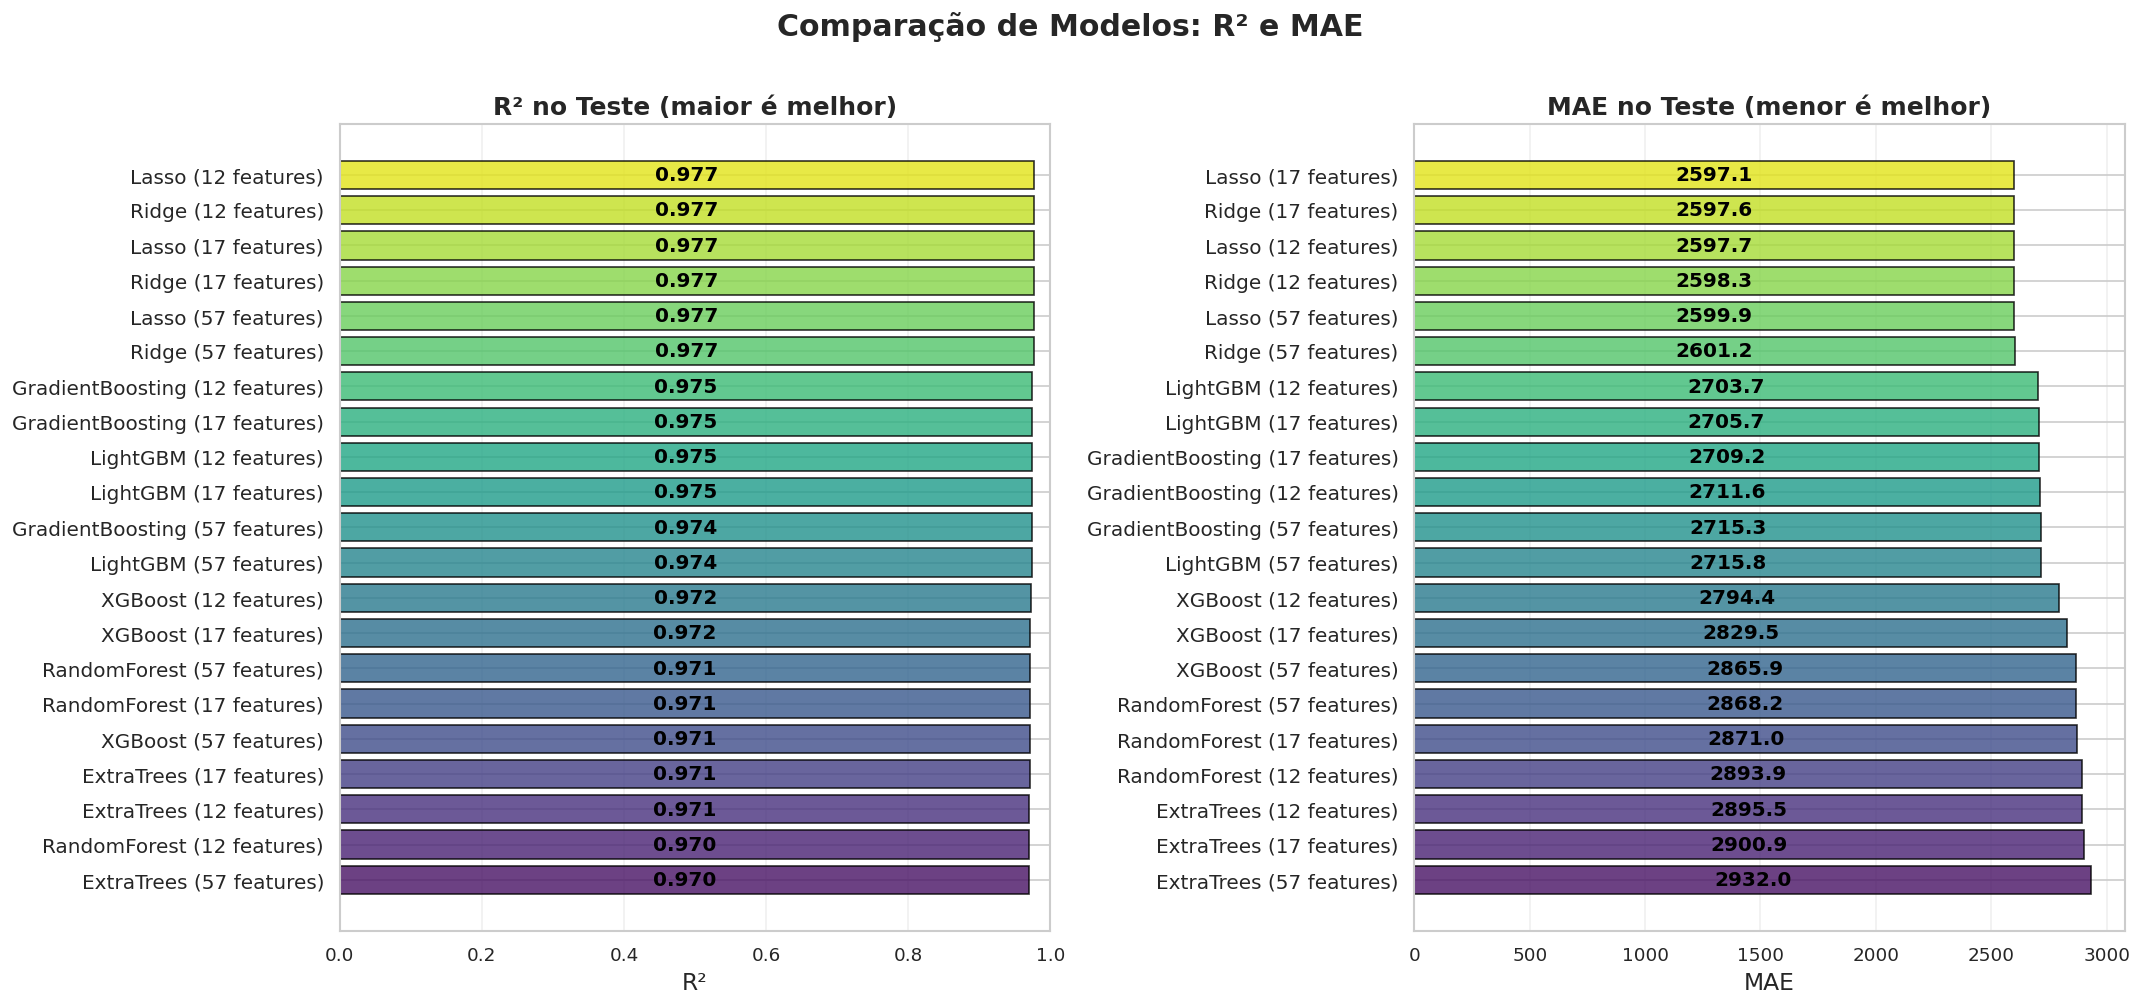

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usar o DataFrame de resultados já existente
resultados = resultados_df.copy()

# Criar um rótulo mais descritivo para incluir o número de features
resultados['Modelo_Features'] = resultados['Modelo'] + ' (' + resultados['Total de Features'].astype(str) + ' features)'

# Criar figura com 1 linha e 2 colunas para os 2 plots horizontais (R² e MAE)
fig, axes = plt.subplots(1, 2, figsize=(18, 9)) # Ajustar tamanho da figura
fig.suptitle('Comparação de Modelos: R² e MAE', fontsize=18, fontweight='bold')

# 1. R² Comparativo
ax = axes[0]
# Sort for R² plot (descending R²)
r_squared_sorted = resultados.sort_values(by=['R²'], ascending=True)
bars = ax.barh(r_squared_sorted['Modelo_Features'], r_squared_sorted['R²'],
              color=sns.color_palette('viridis', n_colors=len(r_squared_sorted)), alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('R²', fontsize=14)
ax.set_title('R² no Teste (maior é melhor)', fontsize=15, fontweight='bold')
ax.set_xlim([0, 1]) # Limite para o eixo X (R²)
ax.grid(True, alpha=0.3, axis='x') # Grid no eixo X para barras horizontais
ax.tick_params(axis='y', labelsize=12) # Rótulos no eixo Y

# Adicionar valores DENTRO das barras
for bar, valor in zip(bars, r_squared_sorted['R²']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.3f}', ha='center', va='center',
            color='black', fontweight='bold', fontsize=12)

# 2. MAE Comparativo
ax = axes[1]
# Sort for MAE plot (ascending MAE)
mae_sorted = resultados.sort_values(by=['MAE'], ascending=False)
bars = ax.barh(mae_sorted['Modelo_Features'], mae_sorted['MAE'],
              color=sns.color_palette('viridis', n_colors=len(mae_sorted)), alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('MAE', fontsize=14)
ax.set_title('MAE no Teste (menor é melhor)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.tick_params(axis='y', labelsize=12)

# Adicionar valores DENTRO das barras
for bar, valor in zip(bars, mae_sorted['MAE']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.1f}', ha='center', va='center',
            color='black', fontweight='bold', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.97]) # Ajustar layout para título superior
plt.show()

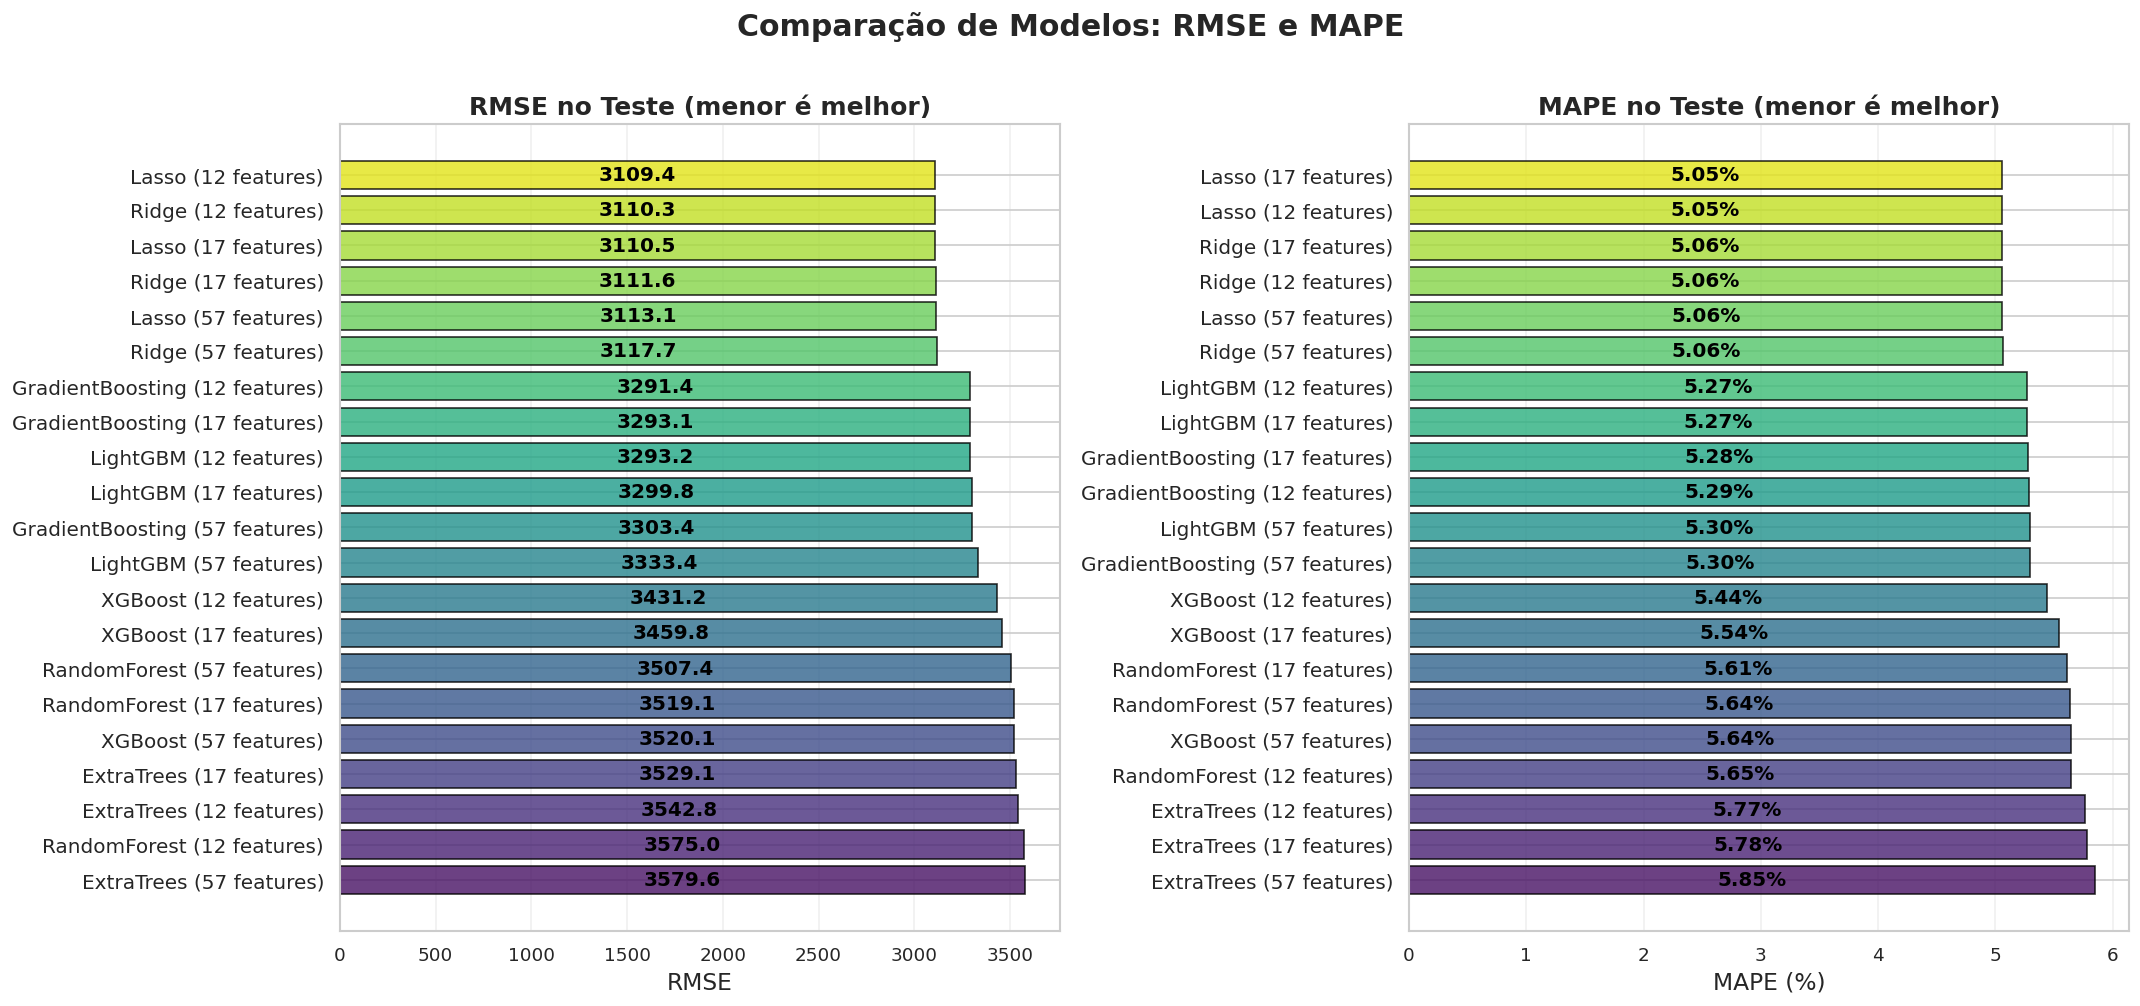

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usar o DataFrame de resultados já existente
resultados = resultados_df.copy()

# Criar um rótulo mais descritivo para incluir o número de features
resultados['Modelo_Features'] = resultados['Modelo'] + ' (' + resultados['Total de Features'].astype(str) + ' features)'

# Criar figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle('Comparação de Modelos: RMSE e MAPE', fontsize=18, fontweight='bold')

# =========================
# 1. RMSE Comparativo
# =========================
ax = axes[0]

# menor é melhor → inverter ordenação visual
rmse_sorted = resultados.sort_values(by=['RMSE'], ascending=False)

bars = ax.barh(rmse_sorted['Modelo_Features'], rmse_sorted['RMSE'],
              color=sns.color_palette('viridis', n_colors=len(rmse_sorted)),
              alpha=0.8, edgecolor='black', linewidth=1)

ax.set_xlabel('RMSE', fontsize=14)
ax.set_title('RMSE no Teste (menor é melhor)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.tick_params(axis='y', labelsize=12)

# valores dentro da barra
for bar, valor in zip(bars, rmse_sorted['RMSE']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.1f}', ha='center', va='center',
            color='black', fontweight='bold', fontsize=12)

# =========================
# 2. MAPE Comparativo
# =========================
ax = axes[1]

# menor é melhor
mape_sorted = resultados.sort_values(by=['MAPE'], ascending=False)

bars = ax.barh(mape_sorted['Modelo_Features'], mape_sorted['MAPE'],
              color=sns.color_palette('viridis', n_colors=len(mape_sorted)),
              alpha=0.8, edgecolor='black', linewidth=1)

ax.set_xlabel('MAPE (%)', fontsize=14)
ax.set_title('MAPE no Teste (menor é melhor)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.tick_params(axis='y', labelsize=12)

# valores dentro da barra
for bar, valor in zip(bars, mape_sorted['MAPE']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.2f}%', ha='center', va='center',
            color='black', fontweight='bold', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

## Pipeline

In [21]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error

features_3= ['Quilometragem', 'Ano', 'Marca']

# Definir X e y
X_full = df[features_3]
y_full = df['Valor_Venda']

# Colunas
categorical_cols = ['Marca']
numerical_cols = ['Ano', 'Quilometragem']

# Pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# 🔥 Pipeline com Lasso
pipeline_with_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', Lasso(alpha=0.01, max_iter=10000))
])

# Split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print("X_full:", X_full.shape)
print("Treino (80%):", X_train_full.shape)
print("Teste (20%):", X_test_full.shape)

# Treinar
pipeline_with_lasso.fit(X_train_full, y_train_full)

# Prever
y_pred = pipeline_with_lasso.predict(X_test_full)

# Métricas
r2 = r2_score(y_test_full, y_pred)
mae = mean_absolute_error(y_test_full, y_pred)

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")

X_full: (9686, 3)
Treino (80%): (7748, 3)
Teste (20%): (1938, 3)
R²: 0.9774
MAE: 2596.85


In [22]:
X_full.columns

Index(['Quilometragem', 'Ano', 'Marca'], dtype='object')


### GridSearch

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'lasso__alpha': [0.001,0.005, 0.01, 0.1]
}

grid = GridSearchCV(
    pipeline_with_lasso,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_full, y_train_full)

print("Melhor alpha:", grid.best_params_)

print("\nGridSearch com Encoder no Pipeline\n Melhores parâmetros:", grid.best_params_)
print("\nMelhor score CV:", grid.best_score_)

best_model_full_pipeline = grid.best_estimator_

test_score_full_pipeline = best_model_full_pipeline.score(X_test_full, y_test_full)
print("R2 no teste:", round(test_score_full_pipeline,4))
y_pred_test_full_pipeline = best_model_full_pipeline.predict(X_test_full)
print(f"MAE teste : {mean_absolute_error(y_test_full, y_pred_test_full_pipeline):.2f}")

Melhor alpha: {'lasso__alpha': 0.001}

GridSearch com Encoder no Pipeline
 Melhores parâmetros: {'lasso__alpha': 0.001}

Melhor score CV: 0.9778023718741385
R2 no teste: 0.9774
MAE teste : 2596.85


### Salvar o melhor modelo gerado com o gridsearch

In [24]:
import joblib

# Salvar o modelo (pipeline completa) para uso futuro
model_filename = 'lasso_best_full_model_pipeline.pkl'
joblib.dump(best_model_full_pipeline, model_filename)

print(f"Modelo salvo em '{model_filename}'")

Modelo salvo em 'lasso_best_full_model_pipeline.pkl'


In [25]:
X_train.columns

Index(['Quilometragem', 'Ano', 'Marca'], dtype='object')